# <span style="color:purple; font-weight:bold; text-decoration:underline;">CESM2.1 Large Ensemble Sulfate Emissions & AOD Timeseries </span>

### <span style="color:purple"> Imports

In [1]:
import xarray as xr

### <span style="color:purple"> Area file and region masks

In [2]:
area = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/area_files/AREA.nc')
East_Asia_mask = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/masks/East_Asia/East_Asia_Mask.nc')
NPAC_mask = xr.open_dataarray('/glade/work/jzweifel/Regional_Masks_And_Area/masks/NPAC/NPAC_mask.nc')

### <span style="color:purple"> Creating Sulfate and AOD timeseries

In [3]:
# -----------------------------------------------------
# Sulfates
# -----------------------------------------------------

SFSO2 = xr.open_dataset("cesm2.1_BHIST_1850-2014_data/b.e21.BHIST.f09_g17.CMIP6-historical.003.cam.h0.SFSO2.185001-201412.nc")["SFSO2"]
# SO2 surface flux, kg/m2/s

SO2_CMXF = xr.open_dataset("cesm2.1_BHIST_1850-2014_data/b.e21.BHIST.f09_g17.CMIP6-historical.003.cam.h0.SO2_CMXF.185001-201412.nc")["SO2_CMXF"]
# Vertically integrated external forcing for SO2, kg/m2/s

total_SO2 = (SFSO2 + SO2_CMXF).where(East_Asia_mask).weighted(area).sum(dim=["lat", "lon"])
# Time series of total kg/s of SO2 flux over East Asia

# -----------------------------------------------------
# Aerosol Optical Depth
# -----------------------------------------------------

AODSO4dn = xr.open_dataset("cesm2.1_BHIST_1850-2014_data/b.e21.BHIST.f09_g17.CMIP6-historical.003.cam.h0.AODSO4dn.185001-201412.nc")["AODSO4dn"]
# Aerosol optical depth 550 nm from SO4, day night

AODSO4dn_NPO = AODSO4dn.where(NPAC_mask).weighted(area).mean(("lat", "lon"))
# Time series of AODSO4 over NPAC



### <span style="color:purple"> Sampling: February, May, August, and November

In [4]:
months = [3, 6, 9, 12]

months_total_SO2 = [total_SO2.where(total_SO2.time.dt.month == m, drop=True) for m in months]

months_AODSO4dn = [AODSO4dn_NPO.where(AODSO4dn_NPO.time.dt.month == m, drop=True) for m in months]

### <span style="color:purple"> Plotting 'Seasonal' Timeseries

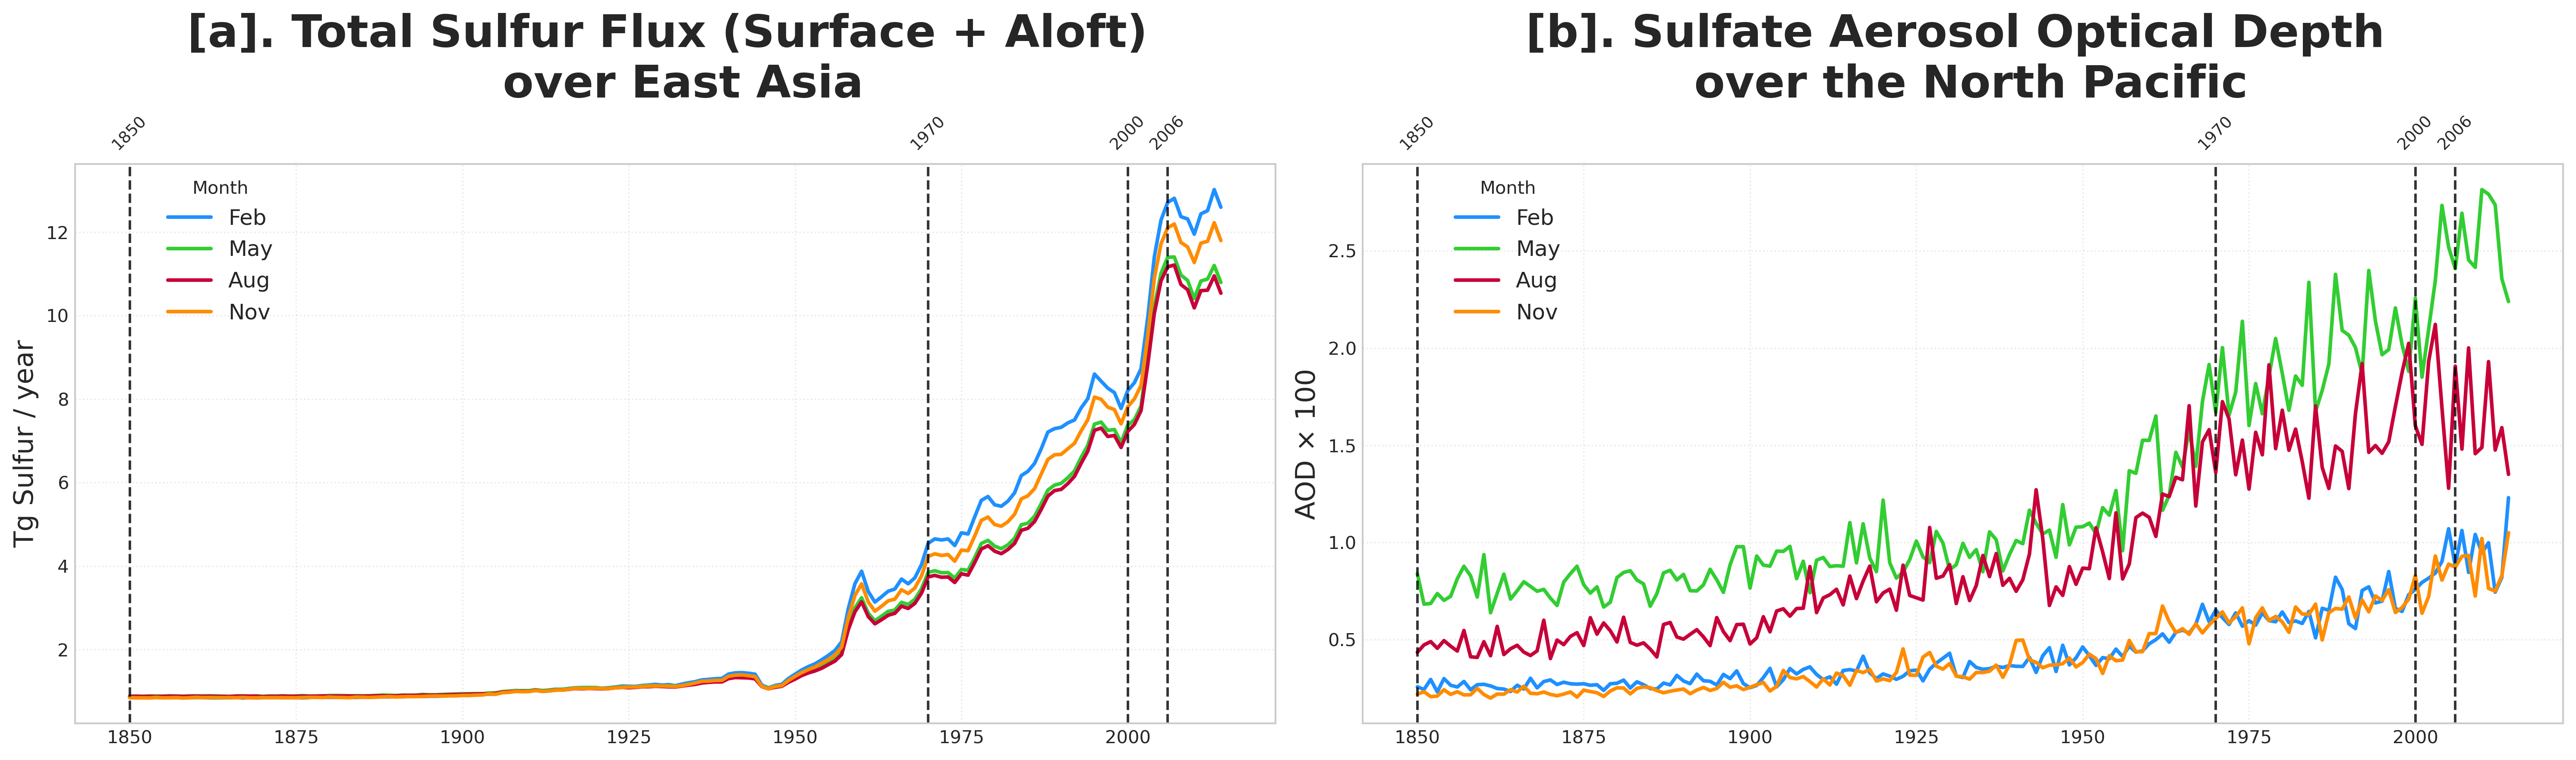

In [14]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Global style
# ---------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'legend.frameon': False, 'lines.linewidth': 2, 'axes.titleweight': 'bold'})

# ---------------------------------------------------------
# Inputs
# ---------------------------------------------------------
labels = ['Feb', 'May', 'Aug', 'Nov']
label_to_color = {'Feb': "#1E90FF", 'May': "#32CD32", 'Aug': "#C70039", 'Nov': "#FF8C00"}
highlight_years = [1850, 1970, 2000, 2006]

# Sulfur conversion constants
seconds_per_year = 60 * 60 * 24 * 365
Kg_to_Tg = 1e-9
S_SO4_ratio = 32.065 / 115.107
multiplier = seconds_per_year * Kg_to_Tg * S_SO4_ratio

# ---------------------------------------------------------
# Create figure
# ---------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(20, 6), dpi=300, sharex=True)

# =========================================================
# Left Pabel: Sulfur flux
# =========================================================
for arr, label in zip(months_total_SO2, labels):
    axs[0].plot(arr.time.dt.year, arr * multiplier, label=label, color=label_to_color[label])

axs[0].set_ylabel("Tg Sulfur / year", fontsize=15)
axs[0].grid(linestyle=':', alpha=0.4)

# --- Vertical timeline markers ---
for year in highlight_years:
    axs[0].axvline(year, linestyle='--', color='black', linewidth=1.4, alpha=0.8)


# =========================================================
# RIGHT PANEL: Sulfate AOD
# =========================================================
for arr, label in zip(months_AODSO4dn, labels):
    axs[1].plot(arr.time.dt.year, arr * 100, label=label, color=label_to_color[label])

axs[1].set_ylabel("AOD × 100", fontsize=15)
axs[1].grid(linestyle=':', alpha=0.4)

# --- Vertical timeline markers ---
for year in highlight_years:
    axs[1].axvline(year, linestyle='--', color='black', linewidth=1.4, alpha=0.8)


# -------------------------
# YEAR LABELS
# -------------------------

# Left panel
ymax0 = axs[0].get_ylim()[1]
for year in highlight_years:
    y_offset = 1.02
    axs[0].text(year, ymax0 * y_offset, str(year), ha='center', va='bottom', fontsize=9, rotation=45)

# Right panel
ymax1 = axs[1].get_ylim()[1]
for year in highlight_years:
    y_offset = 1.02
    axs[1].text(year, ymax1 * y_offset, str(year), ha='center', va='bottom', fontsize=9, rotation=45)

# =========================================================
# TITLES ABOVE EVERYTHING
# =========================================================
axs[0].set_title("[a]. Total Sulfur Flux (Surface + Aloft) \n over East Asia",fontsize=25, y=1.1)

axs[1].set_title("[b]. Sulfate Aerosol Optical Depth \n over the North Pacific",fontsize=25, y=1.1)

# ---------------------------------------------------------
# Legends
# ---------------------------------------------------------
axs[0].legend(title="Month", loc=(0.07, 0.7), fontsize=12)

axs[1].legend(title="Month", loc=(0.07, 0.7), fontsize=12)

# ---------------------------------------------------------
# Layout fixes
# ---------------------------------------------------------
plt.tight_layout()
plt.savefig('/glade/u/home/jzweifel/jupyter_workspaces/Masters_paper_analysis/notebooks/figures/Figure_02/Figure_02.png')
plt.show()